In [1]:
import lecilab_behavior_analysis.utils as utils
import lecilab_behavior_analysis.df_transforms as dft
import lecilab_behavior_analysis.plots as plots
from pathlib import Path
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import time
from village.plots.corridor_plot import corridor_plot
import datetime


%load_ext autoreload
%autoreload 2

In [2]:
# see the available projects
tv_projects = utils.get_server_projects()
for i, p in enumerate(tv_projects):
    print(f"[{i}] {p}")

[0] auditory_escape_data
[1] cate_task_data
[2] COT_cannula_data
[3] COT_test_data
[4] dual2AFC_iDisco_data
[5] empty-project_data
[6] visual_and_COT_data


In [3]:
# select a project
project = tv_projects[4]
print(f"Selected project: {project}")

Selected project: dual2AFC_iDisco_data


In [4]:
# see the available animals
animals = utils.get_animals_in_project(project)
print(animals)

['ACV011', 'ACV012', 'ACV013', 'ACV014', 'ACV015', 'ACV016', 'ACV017', 'ACV018', 'ACV019', 'ACV020', 'ACV021', 'ACV022']


In [5]:
animals = ["ACV012"]

In [6]:
# retrieve the data for the remaining animals
for mouse in animals:
    local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions") / Path(mouse)
    # create the directory if it doesn't exist
    local_path.mkdir(parents=True, exist_ok=True)
    # download the session data
    utils.rsync_cluster_data(
        project_name=project,
        file_path="sessions/{}/{}.csv".format(mouse, mouse),
        local_path=str(local_path),
        credentials=utils.get_idibaps_cluster_credentials(),
    )
# Clear the output of the jupyter cell
clear_output(wait=True)
time.sleep(.5)
print("Data downloaded successfully.")

Data downloaded successfully.


In [7]:
df_list = []
for mouse in animals:
    local_path = Path(utils.get_outpath()) / Path(project) / Path("sessions") / Path(mouse)
    df = pd.read_csv(local_path / Path(f'{mouse}.csv'), sep=";")
    df_list.append(df)
    print(f"Loaded data for {mouse}.")
# concatenate the dataframes
df = pd.concat(df_list, ignore_index=True)
clear_output(wait=True)
time.sleep(.5)
print("Data read successfully.")

Data read successfully.


In [16]:
df = dft.analyze_df(df)

In [15]:
df["test"] = df.apply(utils.is_this_an_early_pokeout_trial, axis=1)

In [21]:
# select the tail of the df
df_selected = df.tail(3000)

In [22]:
# make a plot of performance dependent on the auditory stimulus
df_selected.head()

,session,date,trial,subject,task,system_name,run_mode,Port1In,Port1Out,Port2In,...,auditory_stimulus,correct,correct_side,current_training_stage,difficulty,holding_time,ordered_list_of_events,stimulus_modality,visual_stimulus,water
4399,53,2026-02-15 17:00:26,47,ACV012,TwoAFC,village01,Auto,"[1771171824.750454, 1771171827.781254]","[1771171824.723254, 1771171824.777854]","[1771171826.7298539, 1771171827.117754]",...,"{'high_tones': {'time_0': {21699.0: 0.0, 24523...",True,left,TwoAFC_visual_easy,easy,0.2993,"['Tup', 'Port1Out', 'Port1In', 'Port1Out', 'Po...",visual,"(0.29934874071956286, 0.04989145678659381)",2.0
4400,53,2026-02-15 17:00:26,48,ACV012,TwoAFC,village01,Auto,"[1771171831.5794978, 1771171833.1988978, 17711...","[1771171831.5250978, 1771171831.6879978, 17711...","[1771171832.551198, 1771171833.962998, 1771171...",...,"{'high_tones': {'time_0': {21699.0: 0.0, 24523...",False,left,TwoAFC_visual_easy,easy,0.2996,"['Tup', 'Port1Out', 'Port1In', 'Port1Out', 'Po...",visual,"(0.17871390755711491, 0.029785651259519152)",2.0
4401,53,2026-02-15 17:00:26,49,ACV012,TwoAFC,village01,Auto,[1771171890.871684],[1771171844.6629841],"[1771171845.7282841, 1771171857.167984, 177117...",...,"{'high_tones': {'time_0': {21699.0: 0.0, 24523...",False,left,TwoAFC_visual_easy,easy,0.2996,"['Tup', 'Port1Out', 'Port2In', 'Tup', 'Port2Ou...",visual,"(0.3685411042393334, 0.061423517373222235)",2.0
4402,53,2026-02-15 17:00:26,50,ACV012,TwoAFC,village01,Auto,NaN,[1771171899.793386],"[1771171901.853886, 1771171902.308686, 1771171...",...,"{'high_tones': {'time_0': {21699.0: 0.0, 24523...",True,right,TwoAFC_visual_easy,easy,0.2996,"['Tup', 'Port1Out', 'Port2In', 'Tup', 'Tup', '...",visual,"(0.29405021651075974, 0.04900836941845996)",2.0
4403,53,2026-02-15 17:00:26,51,ACV012,TwoAFC,village01,Auto,[1771171907.149224],[1771171908.338524],"[1771171905.553524, 1771171906.450624, 1771171...",...,"{'high_tones': {'time_0': {21699.0: 0.0, 24523...",False,right,TwoAFC_visual_easy,easy,0.2999,"['Tup', 'Port3In', 'Port3Out', 'Port2In', 'Tup...",visual,"(0.6912668524876027, 0.1152111420812671)",2.0


ValueError: The dataframe must have the following columns: total_evidence_strength

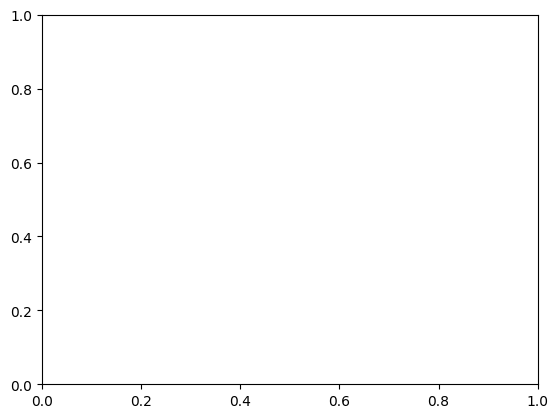

In [23]:
df_selected = dft.get_performance_by_difficulty_ratio(df_selected)
plots.psychometric_plot(df_selected, x = 'total_evidence_strength', y = 'first_choice_numeric', valueType='discrete')

<Axes: xlabel='Leftward Evidence Level', ylabel='Leftward Choices'>

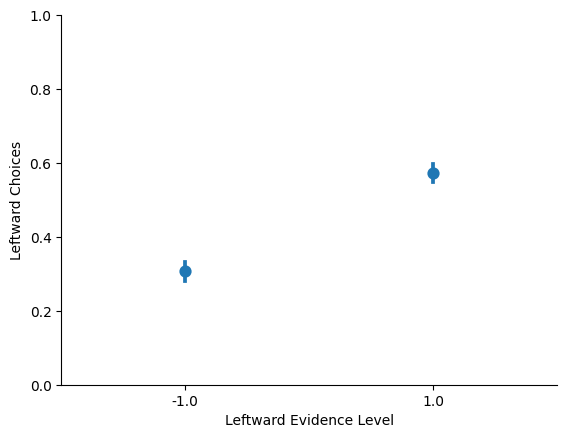

In [27]:
df_selected["side_difficulty"] = df_selected.apply(lambda row: utils.side_and_difficulty_to_numeric(row), axis=1)
df_selected = dft.add_mouse_first_choice(df_selected)
df_selected['first_choice_numeric'] = df_selected['first_choice'].apply(utils.transform_side_choice_to_numeric)
plots.choice_by_difficulty_plot(df_selected)

In [28]:
df_mock = df_selected.copy()
df_mock['stimulus_modality'] = "auditory"
df_mock = dft.get_performance_by_difficulty_ratio(df_mock)
plots.psychometric_plot(df_mock, x = 'total_evidence_strength', y = 'first_choice_numeric', valueType='discrete')

TypeError: eval() arg 1 must be a string, bytes or code object